# 04. GARCH(1,1) 변동성 예측

## 목적
매월 말 기준, 다음 달 개별 종목 월별 실현변동성(`vol_21d`) 예측

## 설계
- 모델: **GARCH(1,1)** — 03 EDA에서 ARCH 효과 85% 유의 확인
- 입력: 직전 60개월 월별 수익률
- 타겟: 다음 달 `vol_21d` (연환산)
- 검증: **Rank IC** (Spearman) + **MSE / QLIKE** 손실함수 (Patton 2011)
- 출력: `data/vol_predicted.csv` — (date, ticker, vol_pred)

## 평가 지표

| 지표 | 단위 | 특징 |
|------|------|------|
| Rank IC | 무차원 | 순위 상관 — 분류 방향성 확인 |
| RMSE | 연환산 vol | 예측 오차 절대 크기 |
| QLIKE | 무차원 | 분산 예측 일관성 — 과소예측에 강한 페널티 (Patton 2011) |

In [4]:
import pandas as pd
import numpy as np
from arch import arch_model
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import warnings, time, platform
from pathlib import Path

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '04_garch'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_WINDOW = 60
MIN_OBS      = 36
START_PRED   = '2011-01-01'
ANN          = np.sqrt(12)

panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])
ret_pivot = panel['ret_1m'].unstack('ticker')
vol_pivot = panel['vol_21d'].unstack('ticker')

all_dates  = ret_pivot.index.sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

패널: (108135, 11)
예측 기간: 2011-01-31 ~ 2025-12-31 (180개월)


# GARCH(1,1) 예측 함수

In [5]:
def predict_garch(r, min_obs=MIN_OBS):
    """
    GARCH(1,1) 1-step ahead 연환산 변동성 예측
    수렴 실패 또는 데이터 부족 시 역사적 변동성으로 대체
    """
    r = r.dropna() * 100  # percent 스케일 (수치 안정성)
    if len(r) < min_obs:
        return float(r.std() * ANN / 100)
    try:
        am  = arch_model(r, vol='Garch', p=1, q=1, dist='normal', rescale=False)
        res = am.fit(disp='off', show_warning=False)
        fc  = res.forecast(horizon=1, reindex=False)
        return float(np.sqrt(fc.variance.values[0, 0]) * ANN / 100)
    except Exception:
        return float(r.std() * ANN / 100)

print('GARCH(1,1) 함수 정의 완료')
print(f'예상 소요 시간: 30~90분 (CPU 환경에 따라 다름)')

GARCH(1,1) 함수 정의 완료
예상 소요 시간: 30~90분 (CPU 환경에 따라 다름)


# Walk-forward 예측 루프

In [6]:
t0 = time.time()
all_records = []
n_fallback  = 0

print(f'GARCH(1,1) Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    idx         = all_dates.get_loc(pred_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
    train_ret   = ret_pivot.reindex(index=train_dates)

    if pred_date not in vol_pivot.index:
        continue
    universe = vol_pivot.loc[pred_date].dropna().index.tolist()

    for ticker in universe:
        if ticker in train_ret.columns:
            vol_pred = predict_garch(train_ret[ticker])
        else:
            vol_pred = np.nan
            n_fallback += 1
        all_records.append({'date': pred_date, 'ticker': ticker, 'vol_pred': vol_pred})

    if (i + 1) % 12 == 0:
        elapsed = time.time() - t0
        eta     = elapsed / (i + 1) * (len(pred_dates) - i - 1)
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)}) '
              f'— 경과 {elapsed/60:.1f}분, 잔여 {eta/60:.1f}분')

print(f'\n완료: {(time.time()-t0)/60:.1f}분  |  예측 {len(all_records):,}개  |  fallback {n_fallback}개')

GARCH(1,1) Walk-forward: 2011-01-31 ~ 2025-12-31
  2011-12-31 (12/180) — 경과 0.3분, 잔여 4.0분
  2012-12-31 (24/180) — 경과 0.6분, 잔여 3.8분
  2013-12-31 (36/180) — 경과 0.9분, 잔여 3.6분
  2014-12-31 (48/180) — 경과 1.2분, 잔여 3.3분
  2015-12-31 (60/180) — 경과 1.5분, 잔여 3.0분
  2016-12-31 (72/180) — 경과 1.8분, 잔여 2.7분
  2017-12-31 (84/180) — 경과 2.1분, 잔여 2.4분
  2018-12-31 (96/180) — 경과 2.4분, 잔여 2.1분
  2019-12-31 (108/180) — 경과 2.7분, 잔여 1.8분
  2020-12-31 (120/180) — 경과 3.0분, 잔여 1.5분
  2021-12-31 (132/180) — 경과 3.4분, 잔여 1.2분
  2022-12-31 (144/180) — 경과 3.7분, 잔여 0.9분
  2023-12-31 (156/180) — 경과 4.1분, 잔여 0.6분
  2024-12-31 (168/180) — 경과 4.5분, 잔여 0.3분
  2025-12-31 (180/180) — 경과 4.9분, 잔여 0.0분

완료: 4.9분  |  예측 79,135개  |  fallback 0개


# Rank IC (참고용)\n",
    "\n",
    "어느 방법이 더 나은지는 포트폴리오 성과로 판단한다.  \n",
    "Rank IC는 예측 정확도 참고용으로만 확인한다.

In [7]:
# ── 저장 ─────────────────────────────────────────────────────
vol_pred_df = pd.DataFrame(all_records)
vol_pred_df['date'] = pd.to_datetime(vol_pred_df['date'])
vol_pred_df.to_csv(DATA_DIR / 'vol_predicted.csv', index=False)
print(f'저장: {DATA_DIR}/vol_predicted.csv  ({len(vol_pred_df):,}행)')

# ── Rank IC 평가 ─────────────────────────────────────────────
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack()
ic_records = []

for pred_date in pred_dates:
    if pred_date not in vol_pred_pivot.index or pred_date not in vol_pivot.index:
        continue
    pred   = vol_pred_pivot.loc[pred_date].dropna()
    actual = vol_pivot.loc[pred_date].dropna()
    common = pred.index.intersection(actual.index)
    if len(common) < 30:
        continue
    ic, _ = spearmanr(pred[common], actual[common])
    ic_records.append({'date': pred_date, 'ic': ic})

ic_df = pd.DataFrame(ic_records).set_index('date')

print('\n' + '='*50)
print('GARCH(1,1) Rank IC (예측 vol vs 실제 vol_21d)')
print('='*50)
print(f'  평균 IC:    {ic_df["ic"].mean():.4f}')
print(f'  중앙값 IC:  {ic_df["ic"].median():.4f}')
print(f'  양수 비율:  {(ic_df["ic"] > 0).mean():.1%}')
print(f'  ICIR:       {ic_df["ic"].mean() / ic_df["ic"].std():.4f}')
print(f'\n  [비교] AR(1) baseline R² 중앙값: 0.235 (03 결과)')

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/data/vol_predicted.csv  (79,135행)

GARCH(1,1) Rank IC (예측 vol vs 실제 vol_21d)
  평균 IC:    0.5874
  중앙값 IC:  0.5855
  양수 비율:  100.0%
  ICIR:       7.2854

  [비교] AR(1) baseline R² 중앙값: 0.235 (03 결과)


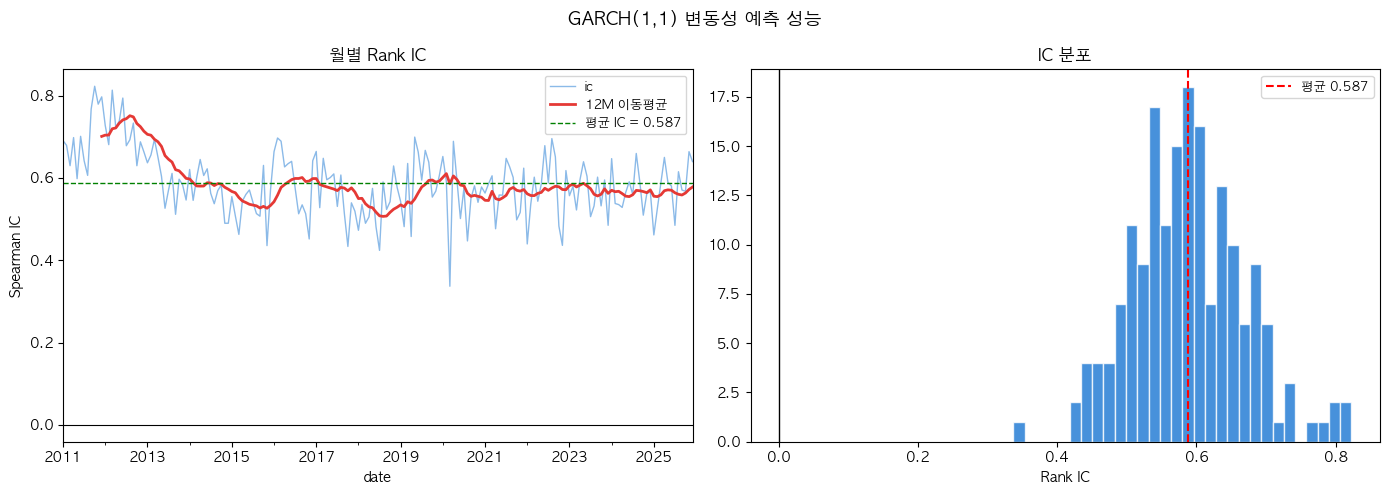

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GARCH(1,1) 변동성 예측 성능', fontsize=13, fontweight='bold')

ax = axes[0]
ic_df['ic'].plot(ax=ax, color='#1976D2', alpha=0.5, linewidth=1)
ic_df['ic'].rolling(12).mean().plot(ax=ax, color='#E53935', linewidth=2,
                                     label=f'12M 이동평균')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(ic_df['ic'].mean(), color='green', linewidth=1, linestyle='--',
           label=f'평균 IC = {ic_df["ic"].mean():.3f}')
ax.set_title('월별 Rank IC')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(ic_df['ic'], bins=30, color='#1976D2', alpha=0.8, edgecolor='white')
ax.axvline(ic_df['ic'].mean(), color='red', linestyle='--',
           label=f'평균 {ic_df["ic"].mean():.3f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('IC 분포')
ax.set_xlabel('Rank IC')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'garch_rank_ic.png', dpi=150, bbox_inches='tight')
plt.show()

# MSE / QLIKE 손실함수 평가

Rank IC는 순위 상관만 본다. MSE와 QLIKE는 예측 오차의 **크기**를 직접 평가한다.

## 손실함수 정의

$$L_{\text{MSE}}(\hat{\sigma}_t,\, \sigma_t) = (\hat{\sigma}_t - \sigma_t)^2$$

$$L_{\text{QLIKE}}(\hat{h}_t,\, \sigma^2_t) = \frac{\hat{h}_t}{\sigma^2_t} - \log\!\left(\frac{\hat{h}_t}{\sigma^2_t}\right) - 1$$

- $\hat{\sigma}_t$: GARCH 예측 연환산 변동성, $\hat{h}_t = \hat{\sigma}_t^2$ (예측 분산)  
- $\sigma_t$: 실현 변동성(`vol_21d`), $\sigma^2_t$ (실현 분산)  
- QLIKE 최솟값 = 0 (완벽 예측 시), **과소예측에 더 강한 페널티**  
- Patton (2011): 노이즈가 있는 변동성 대리지표 하에서도 QLIKE는 일관된(consistent) 손실함수

## 예측 vs 실현 시점 구분 (look-ahead bias 방지)

| 변수 | 관측 가능 시점 | 내용 |
|------|--------------|------|
| `vol_pred` at t | t 이전 데이터로 추정 → t에 관측 가능 | GARCH 1-step ahead 예측 |
| `vol_21d` at t | t 시점 기준 trailing 21일 실현 변동성 | 사후 확인 가능한 실현값 |

두 변수 모두 시점 t에 알 수 있는 값이므로 look-ahead bias 없음.

GARCH(1,1) MSE / QLIKE 손실함수  (비캡핑, Patton 2011)
  RMSE  평균:         0.1347
  RMSE  중앙값:       0.1220
  QLIKE 평균:         1099.73  ← 레짐 전환기 이상치 포함
  QLIKE 중앙값:       0.3805  ← 주 보고 지표
  Naive QLIKE 중앙값: 0.3777  (AR(0) 기준선)
  GARCH vs Naive: Naive 우수
  [비교] Rank IC 평균: 0.5874


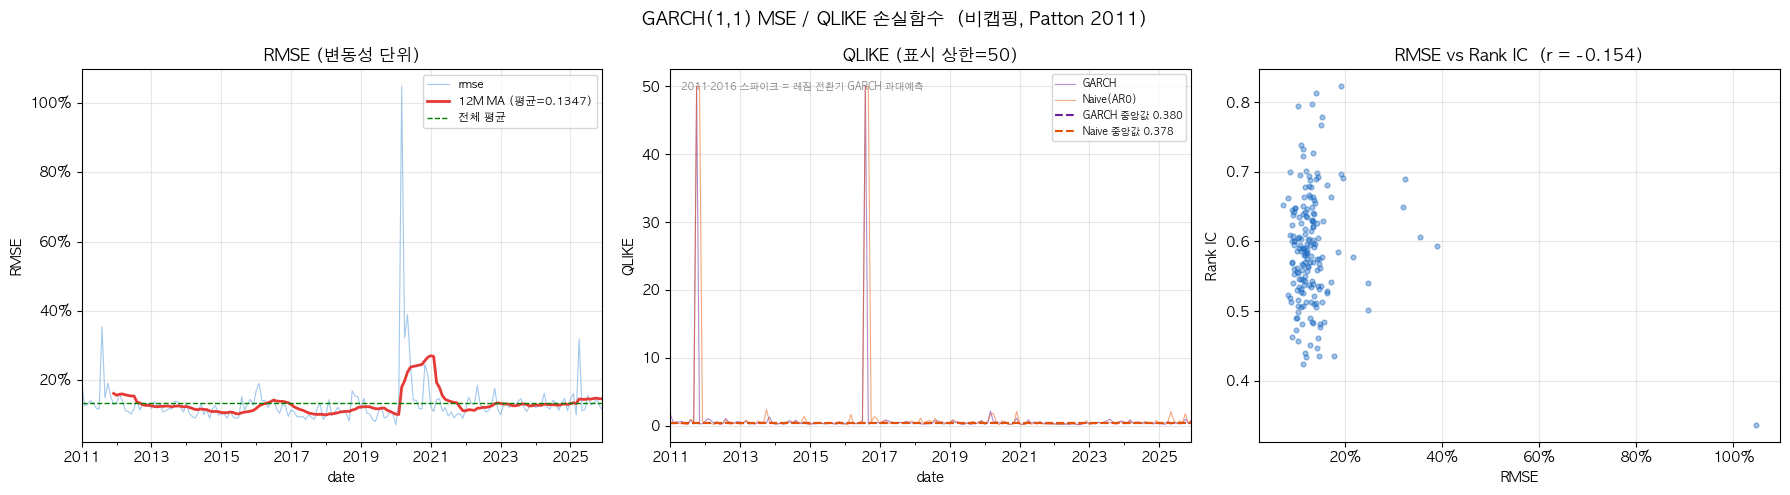

연도별 중앙값 QLIKE (GARCH vs Naive) / RMSE:
      연도       GARCH       Naive      RMSE
    2011      0.4985      0.3481    0.1622  ← 레짐 전환
    2012      0.5769      0.3339    0.1279
    2013      0.4496      0.4472    0.1235
    2014      0.3398      0.4784    0.1098
    2015      0.2738      0.3586    0.1133
    2016      0.3434      0.6441    0.1352  ← 레짐 전환
    2017      0.4682      0.4412    0.1014
    2018      0.2971      0.4679    0.1217
    2019      0.3645      0.4440    0.1063
    2020      0.3983      0.4832    0.2665  ← 레짐 전환
    2021      0.3223      0.2561    0.1127
    2022      0.2383      0.2325    0.1349
    2023      0.4594      0.3702    0.1270
    2024      0.4220      0.3671    0.1304
    2025      0.3262      0.4725    0.1470


In [9]:
import matplotlib.ticker as mtick

# ── MSE / QLIKE 계산 ──────────────────────────────────────────
# QLIKE = ĥ/σ² - log(ĥ/σ²) - 1  (Patton 2011, 분산 단위, 비캡핑)
#
# 평균 QLIKE는 레짐 전환기(2011 금융위기 회복, 2016 등) 극단값에 크게 끌린다.
# → 주 보고 지표: 중앙값. 평균은 GARCH의 레짐 전환 취약성 참고용.
#
# Naive baseline 추가: 직전 달 vol_21d를 그대로 사용 (AR(0) 기준선)
# → GARCH QLIKE < Naive QLIKE 이면 GARCH가 유의미한 개선

mse_records         = []
qlike_records       = []
naive_qlike_records = []

prev_vol = {}  # {ticker: 직전 달 실현 vol}

for pred_date in pred_dates:
    if pred_date not in vol_pred_pivot.index or pred_date not in vol_pivot.index:
        continue
    pred_vol   = vol_pred_pivot.loc[pred_date].dropna()
    actual_vol = vol_pivot.loc[pred_date].dropna()
    common     = pred_vol.index.intersection(actual_vol.index)
    if len(common) < 30:
        continue

    p = pred_vol[common].values
    a = actual_vol[common].values

    mse = float(np.mean((p - a) ** 2))
    mse_records.append({"date": pred_date, "mse": mse, "rmse": np.sqrt(mse)})

    h_var = p ** 2
    sig2  = np.clip(a ** 2, 1e-8, None)
    ratio = h_var / sig2
    qlike = float(np.mean(ratio - np.log(ratio) - 1))
    qlike_records.append({"date": pred_date, "qlike": qlike})

    naive_preds = np.array([prev_vol.get(t, np.nan) for t in common])
    valid = ~np.isnan(naive_preds)
    if valid.sum() >= 10:
        pn = naive_preds[valid] ** 2
        an = sig2[valid]
        rn = pn / an
        naive_qlike_records.append({
            "date": pred_date,
            "qlike": float(np.mean(rn - np.log(rn) - 1))
        })

    for t, v in zip(common, a):
        prev_vol[t] = float(v)

mse_df         = pd.DataFrame(mse_records).set_index("date")
qlike_df       = pd.DataFrame(qlike_records).set_index("date")
naive_qlike_df = pd.DataFrame(naive_qlike_records).set_index("date")

print("=" * 62)
print("GARCH(1,1) MSE / QLIKE 손실함수  (비캡핑, Patton 2011)")
print("=" * 62)
print(f"  RMSE  평균:         {mse_df['rmse'].mean():.4f}")
print(f"  RMSE  중앙값:       {mse_df['rmse'].median():.4f}")
print(f"  QLIKE 평균:         {qlike_df['qlike'].mean():.2f}  ← 레짐 전환기 이상치 포함")
print(f"  QLIKE 중앙값:       {qlike_df['qlike'].median():.4f}  ← 주 보고 지표")
print(f"  Naive QLIKE 중앙값: {naive_qlike_df['qlike'].median():.4f}  (AR(0) 기준선)")
garch_better = qlike_df["qlike"].median() < naive_qlike_df["qlike"].median()
print(f"  GARCH vs Naive: {'GARCH 우수' if garch_better else 'Naive 우수'}")
print(f"  [비교] Rank IC 평균: {ic_df['ic'].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GARCH(1,1) MSE / QLIKE 손실함수  (비캡핑, Patton 2011)",
             fontsize=13, fontweight="bold")

ax = axes[0]
mse_df["rmse"].plot(ax=ax, color="#1976D2", alpha=0.4, linewidth=0.8)
mse_df["rmse"].rolling(12).mean().plot(ax=ax, color="#E53935", linewidth=2,
    label=f"12M MA (평균={mse_df['rmse'].mean():.4f})")
ax.axhline(mse_df["rmse"].mean(), color="green", linestyle="--", linewidth=1, label="전체 평균")
ax.set_title("RMSE (변동성 단위)")
ax.set_ylabel("RMSE")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
DISPLAY_CAP = 50
qlike_df["qlike"].clip(upper=DISPLAY_CAP).plot(
    ax=ax, color="#6A1B9A", alpha=0.5, linewidth=0.8, label="GARCH")
naive_qlike_df["qlike"].clip(upper=DISPLAY_CAP).plot(
    ax=ax, color="#E65100", alpha=0.5, linewidth=0.8, label="Naive(AR0)")
ax.axhline(qlike_df["qlike"].median(), color="#6A1B9A", linestyle="--",
           linewidth=1.5, label=f"GARCH 중앙값 {qlike_df['qlike'].median():.3f}")
ax.axhline(naive_qlike_df["qlike"].median(), color="#E65100", linestyle="--",
           linewidth=1.5, label=f"Naive 중앙값 {naive_qlike_df['qlike'].median():.3f}")
ax.set_title(f"QLIKE (표시 상한={DISPLAY_CAP})")
ax.set_ylabel("QLIKE")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, "2011·2016 스파이크 = 레짐 전환기 GARCH 과대예측",
        transform=ax.transAxes, va="top", fontsize=7, color="gray")

ax = axes[2]
common_dates = mse_df.index.intersection(ic_df.index)
ax.scatter(mse_df.loc[common_dates, "rmse"], ic_df.loc[common_dates, "ic"],
           alpha=0.4, s=12, color="#1565C0")
corr = np.corrcoef(mse_df.loc[common_dates, "rmse"], ic_df.loc[common_dates, "ic"])[0, 1]
ax.set_xlabel("RMSE")
ax.set_ylabel("Rank IC")
ax.set_title(f"RMSE vs Rank IC  (r = {corr:.3f})")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "garch_mse_qlike.png", dpi=150, bbox_inches="tight")
plt.show()

annual_qlike       = qlike_df["qlike"].resample("YE").median()
annual_naive_qlike = naive_qlike_df["qlike"].resample("YE").median()
annual_rmse        = mse_df["rmse"].resample("YE").mean()

print("연도별 중앙값 QLIKE (GARCH vs Naive) / RMSE:")
print(f"  {'연도':>6}  {'GARCH':>10}  {'Naive':>10}  {'RMSE':>8}")
for yr in annual_qlike.index:
    q = annual_qlike.get(yr, float("nan"))
    n = annual_naive_qlike.get(yr, float("nan"))
    r = annual_rmse.get(yr, float("nan"))
    flag = "  ← 레짐 전환" if yr.year in (2011, 2016, 2020) else ""
    print(f"  {yr.year:>6}  {q:>10.4f}  {n:>10.4f}  {r:>8.4f}{flag}")


# 저장 확인
`cell-03`에서 GARCH 예측 완료 즉시 저장됨. 이 셀은 저장 결과를 확인한다.

출력 형식: `date, ticker, vol_pred` (long format)  
다음 단계 (`99_baseline.ipynb` GARCH 섹션)에서 이 파일을 로드해 P 행렬 분류에 사용.

In [10]:
# cell-03에서 이미 저장 완료 — 저장 결과 확인
saved = pd.read_csv(DATA_DIR / 'vol_predicted.csv', parse_dates=['date'])
print(f'vol_predicted.csv 확인')
print(f'  행수:  {len(saved):,}')
print(f'  컬럼:  {list(saved.columns)}')
print(f'  기간:  {saved["date"].min().date()} ~ {saved["date"].max().date()}')
print(f'  종목수: {saved["ticker"].nunique()}개')
print()
print(saved.head(3).to_string(index=False))

vol_predicted.csv 확인
  행수:  79,135
  컬럼:  ['date', 'ticker', 'vol_pred']
  기간:  2011-01-31 ~ 2025-12-31
  종목수: 610개

      date ticker  vol_pred
2011-01-31      A  0.414694
2011-01-31     AA  0.452712
2011-01-31   AAPL  0.352618
